# 03 - Feature Engineering

Apply RFM scoring and rule-based segmentation on top of the RFM metrics
computed in `02_exploratory_data_analysis.ipynb`. This produces the
`Segment` labels (Champion, Loyal Customer, Big Spender, At Risk, Lost,
Others) used for rule-based reporting, independent of the K-Means
clustering done in `04_modeling.ipynb`.

In [1]:
import os
import sys

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

sys.path.append(os.getcwd())

from src.data.load_data import load_config, load_raw_data
from src.data.preprocess import clean_transactions
from src.features.feature_engineering import assign_segments, compute_rfm, score_rfm

config = load_config("config.yaml")
raw = load_raw_data(config)
clean = clean_transactions(raw)
rfm = compute_rfm(clean, config["rfm"]["reference_date_offset_days"])

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


## RFM Scoring

Each of Recency, Frequency, and Monetary is rank-transformed and split
into quintiles (1-5). Recency is scored so that lower values (more
recent purchases) get a higher score; Frequency and Monetary are scored
so that higher values get a higher score. Scores combine into a single
`RFM_Score` string (e.g. `"555"` for a top scorer on all three).

In [2]:
rfm = score_rfm(rfm, config["rfm"]["n_bins"])
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,5,115
12347.0,2,7,4310.00,5,5,5,555
12348.0,75,4,1797.24,2,4,4,244
12349.0,19,1,1757.55,4,1,4,414
12350.0,310,1,334.40,1,1,2,112


## Rule-Based Segmentation

Scores are mapped to descriptive segments using the rules in
`src/features/feature_engineering.py` (`_segment_customer`).

In [3]:
rfm = assign_segments(rfm)
rfm["Segment"].value_counts()

Segment
Others            1831
At Risk           1074
Loyal Customer     773
Champion           348
Lost               201
Big Spender        111
Name: count, dtype: int64

## Segment Visualizations

Using the plotting functions from `src/visualization/plots.py` --
these are the same functions `main.py` uses to generate the official
report figures in `reports/figures/`.

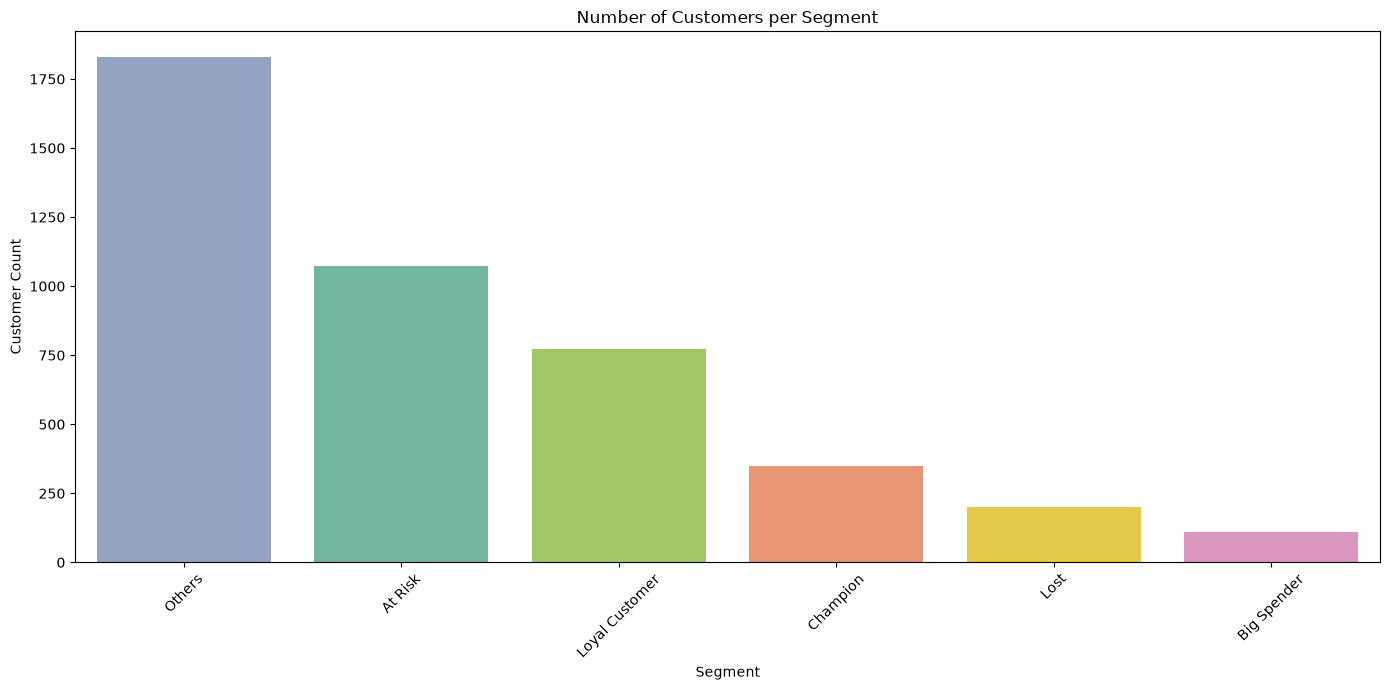

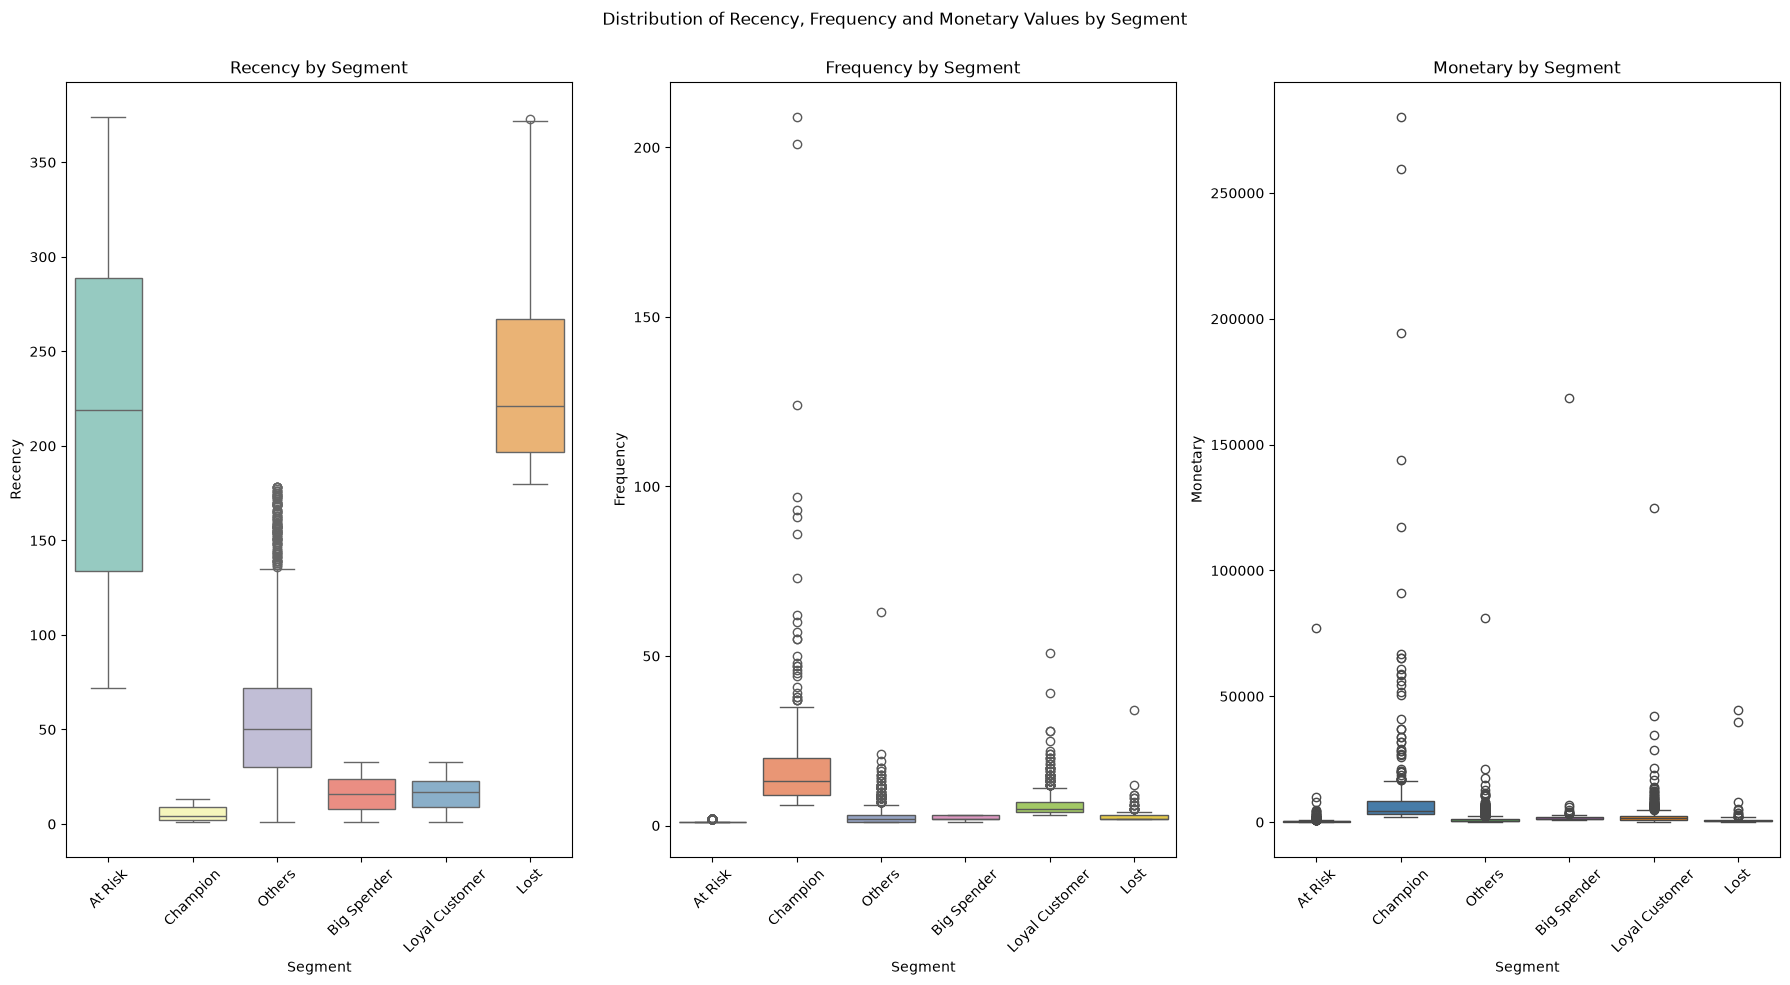

In [4]:
from src.visualization.plots import plot_rfm_distribution_by_segment, plot_segment_counts

_ = plot_segment_counts(rfm, config["reports"]["figures_dir"])
_ = plot_rfm_distribution_by_segment(rfm, config["reports"]["figures_dir"])